<a href="https://colab.research.google.com/github/zahira456/Zahira-Nur-Asyifa_2411532015_ML2526/blob/main/Praktikum2/GaussianNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")

In [2]:
dataset_url = 'https://raw.githubusercontent.com/zahira456/Zahira-Nur-Asyifa_2411532015_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
data = pd.read_csv(dataset_url)
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


<Axes: >

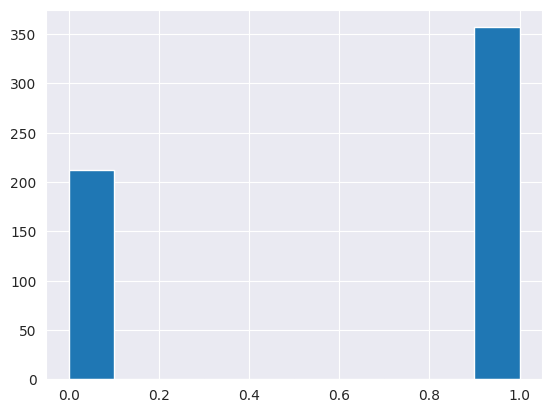

In [3]:
data["diagnosis"].hist()

<Axes: >

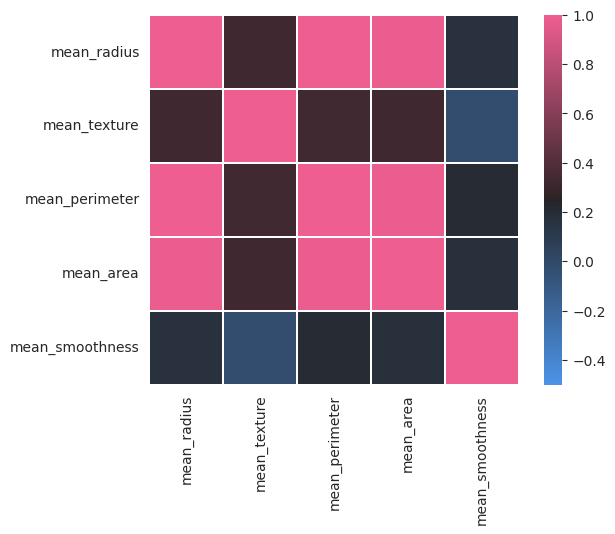

In [7]:
corr = data.iloc[:, :-1].corr(method="pearson")
cmap = sns.diverging_palette(250,354,80,60,center='dark',as_cmap=True)
sns.heatmap(corr, vmax=1, vmin=-.5, cmap=cmap, square=True, linewidths=.2)

<Axes: xlabel='mean_texture', ylabel='Count'>

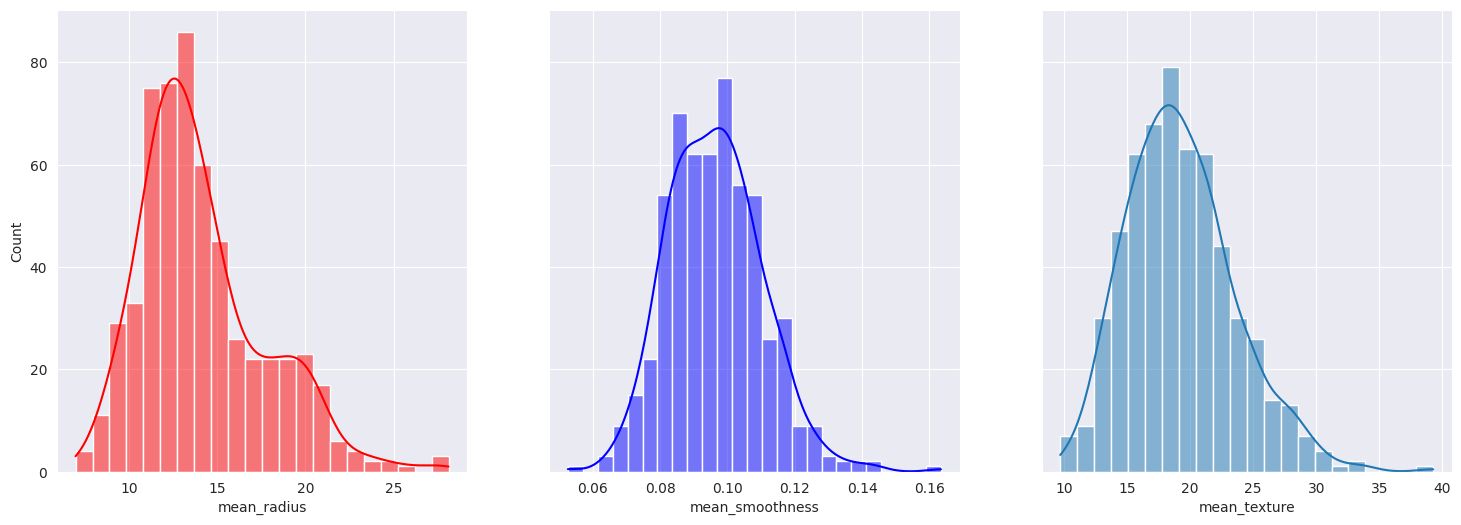

In [8]:
fig, axes= plt.subplots(1, 3, figsize=(18,6), sharey=True)
sns.histplot(data, ax=axes[0], x="mean_radius", kde=True, color='r')
sns.histplot(data, ax=axes[1], x="mean_smoothness", kde=True, color='b')
sns.histplot(data, ax=axes[2], x="mean_texture", kde=True)

In [11]:
def calculate_prior(df, Y):
  classes = sorted(list(df[Y].unique()))
  prior = []
  for i in classes:
    prior.append(len(df[df[Y]==i])/len(df))
  return prior

In [12]:
def calculate_likehood_gaussian(df, feat_name, feat_val, Y, label):
  feat = list(df.columns)
  df = df[df[Y]==label]
  mean, std = df[feat_name].mean(), df[feat_name].std()
  p_x_given_y = (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((feat_val-mean)**2 / (2*std**2)))
  return p_x_given_y

In [13]:
def naive_bayes_gaussian(df, X, Y):
  features = list(df.columns)[:-1]
  prior = calculate_prior(df, Y)
  Y_pred = []
  for x in X:
    labels = sorted(list(df[Y].unique()))
    likelihood = [1]*len(labels)
    for j in range(len(labels)):
      for i in range(len(features)):
        likelihood[j] *= calculate_likehood_gaussian(df, features[i], x[i], Y, labels[j])

    post_prob = [1]*len(labels)
    for j in range(len(labels)):
      post_prob[j] = likelihood[j] * prior[j]

    Y_pred.append(np.argmax(post_prob))

  return np.array(Y_pred)

In [33]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=.2, random_state=41)

X_test = test.iloc[:,:-1].values
y_test = test.iloc[:,-1].values
y_pred = naive_bayes_gaussian(train, X=X_test, Y="diagnosis")

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
print('Akurasi = ', accuracy_score(y_test, y_pred))
print('F1-score = ', f1_score(y_test, y_pred))



Akurasi =  0.9473684210526315
F1-score =  0.96


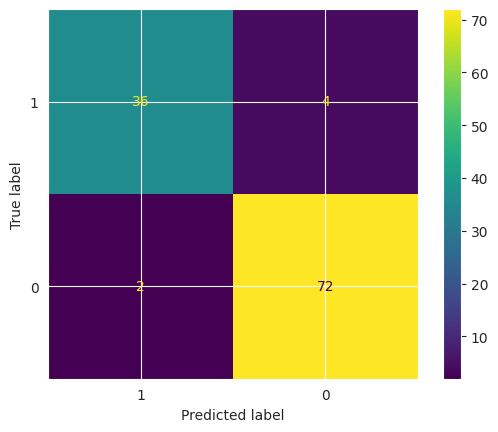

In [34]:
from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay
)
labels = [1, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();

In [21]:
print(data['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: int64
